# Introduction


**File:** Notebook_to_build_graphics.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 10.03.2026
\
**Problem:** Here there are two:
 1) Plot $\psi(x)$
 2) Test our model for $M_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$

This code contains two short exercises. The first is just a sample of a run of our derivative grid code, which plots the IVP solutions for $\psi(x)$ The second is a short Monte Carlo test of our model for $M_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$, which contains both visual and numerical analysis.

# Derivative Grids

This is the code used for building the derivative grid graphs with the deriv_grid class of my library.

In [ ]:
#--LIBRARIES--------

#numerics
import numpy as np
import eelib

#--CODE--

# set parameters
# note that k, B, and R are percents here, mu is not as its scale is unknown
k = 0.625
R = 0.8
B = 0.5
mu = 1.0e-7

n_g = 4

pr = 1000
n = 2

loopl = eelib.deriv_grid(R, B, k, mu, grid_size=n_g)
loopl.derivGrid()


# --- PLOTTING FOR GRIDS ---
for i in range(n_g):
    for j in range(n_g):
        loopl.plot_abs(i,j,k,R,B,mu,n)
        loopl.plot_real(i,j,k,R,B,mu,n)

# Test of Slow Oscillation Wavenumber Model

This is code to visually and numerically test the fit of my slow oscillation model. The model is not perfect, but good enough.

In [1]:
import eelib
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as mtc
from sklearn.metrics import root_mean_squared_error

In [17]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-6

n_mc = 1000

b_r  = (0.5, 1.0)  # B here is B*R
mu_r = (-8, -6)    # 1.0e-8 to 1.0e-6
k_r = (0.1,0.9)


In [18]:
rms_ratio_graph = np.sqrt(1000) / np.sqrt(999)
rms_ratio_fin = np.sqrt(n_mc)/ np.sqrt(n_mc - 1)

In [19]:
#--CODE--

# Make the grid object
gridl = eelib.grid_slow_osc(R, B, dk, mu)

# Save our full solution
gridl.save_solution = True

# Make the grid
gridl.makeMCPoints(mu=mu_r, dk=k_r, B=b_r, num = n_mc)

# Run the grid
gridl.mcSlowOsc()

Begin grid build:  0.0
Number of periods to calculate: 1000
Done grid build:  44637.97617340088


In [20]:
import pickle
filename = 'grid201'

# Since this takes a while to run and is used for a while, it is best to save a copy of the data.
file = open(filename, 'ab')
pickle.dump(gridl, file)
file.close()

In [21]:
# First, declare which solution I am using
ii  = int(np.random.rand()*n_mc)
#if ii >= n_mc: ii = n_mc - 1 # just in case
sol = gridl.slow_osc_sol[ii]
#sol1 = gridl.slow_osc_sol_1[ii]

# Retrieve my fits for this function from the grid.
MM    = gridl.slow_osc_k[ii]
amp   = gridl.slow_osc_a[ii]
theta = gridl.slow_osc_th[ii]

# Predicted slow oscillation amplitude.
vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

# Pull the found solution from the sol variable.
t_list  = sol['t'][:-1]
y1_list = np.real(sol['y'][0][:-1])

# Estimated fit
y2_list = amp * np.sin(MM2 * (t_list) + theta)

# Fit to a sin using SciPy
y3_list = amp * np.sin(MM * t_list + theta)

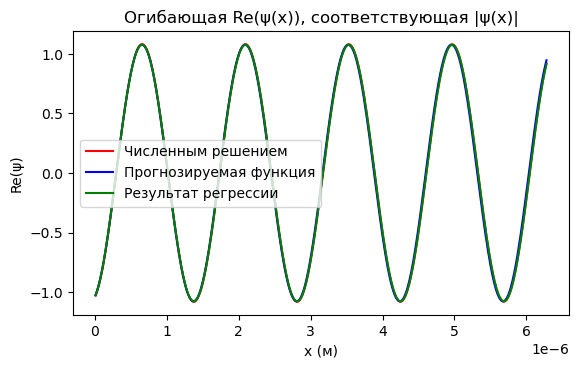

In [22]:
# And plot the results
fig, ax = plt.subplots()

ax.set_ylabel('Re(ψ)')
ax.set_xlabel('x (м)')
plt.title(f"Огибающая Re(ψ(x)), соответствующая |ψ(x)|")

line1, = ax.plot(t_list, y1_list, color = 'red', label = 'Численным решением')
line2, = ax.plot(t_list, y2_list, color = 'blue', label = 'Прогнозируемая функция')
line3, = ax.plot(t_list, y3_list, color = 'green', label = 'Результат регрессии')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.savefig("matchMivp007.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [23]:
print(root_mean_squared_error(y1_list, y2_list)/np.max(np.abs(y1_list)))
print(root_mean_squared_error(y1_list, y3_list)/np.max(np.abs(y1_list)))
print(root_mean_squared_error(y2_list, y3_list)/np.max(np.abs(y1_list)))

0.022352789520091402
0.00417334989346161
0.024841891839640105


In [24]:
print(mtc.mean_absolute_percentage_error(y1_list, y2_list))
print(mtc.mean_absolute_percentage_error(y1_list, y3_list))
print(mtc.mean_absolute_percentage_error(y2_list, y3_list))

0.18709859326252856
0.02837924751746226
0.3188489333384147


In [25]:
print(mtc.r2_score(y1_list, y2_list))
print(mtc.r2_score(y1_list, y3_list))
print(mtc.r2_score(y2_list, y3_list))
#print(mtc.mean_absolute_percentage_error(y1_list, y2_list))
#print(mtc.mean_absolute_percentage_error(y1_list, y3_list))
#print(mtc.mean_absolute_percentage_error(y2_list, y3_list))

0.9989729892476248
0.9999642001565069
0.9987229834426149


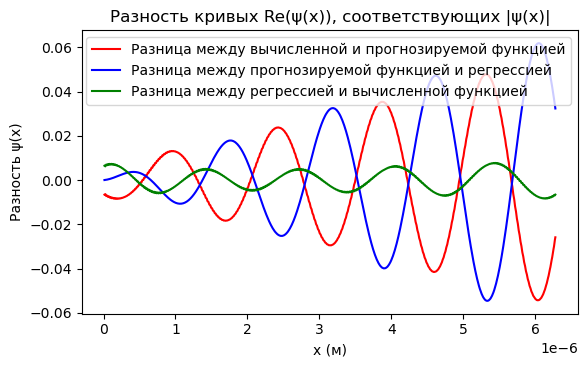

In [26]:
# Plot differences
fig, ax = plt.subplots()

ax.set_ylabel('Разность ψ(x)')
ax.set_xlabel('x (м)')
plt.title(f"Разность кривых Re(ψ(x)), соответствующих |ψ(x)|")

line1, = ax.plot(t_list, y1_list-y2_list, color = 'red', label = 'Разница между вычисленной и прогнозируемой функцией')
line2, = ax.plot(t_list, y2_list-y3_list, color = 'blue', label = 'Разница между прогнозируемой функцией и регрессией')
line3, = ax.plot(t_list, y3_list-y1_list, color = 'green', label = 'Разница между регрессией и вычисленной функцией')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.savefig("matchMivp008.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [27]:
for ii in range(n_mc):
    print(np.abs(gridl.slow_osc_sol_1[ii]-gridl.slow_osc_sol[ii]['y'][0][-1]))

0.09775897275494408
0.0633138456873744
0.13071640196112455
0.07950056153827781
0.19237562998359634
0.10139963252671166
0.12752261511300403
0.08846710924399709
0.10667374870871728
0.03516994980887053
0.054522470546493944
0.07346707242336173
0.08797894744306828
0.022526761906996373
0.14028726738807382
0.18764196739639818
0.021225305691812434
0.02938157319845791
0.08501017908151522
0.016861309242248112
0.0660090778846363
0.06793936294034235
0.04667002087050154
0.016853086672259262
0.1323625326681879
0.1829552619334941
0.04977594248761297
0.08646991728440723
0.09658580713246329
0.13677063003832554
0.02675470006947786
0.02813952954570737
0.16400454726557218
0.08578264607960033
0.08891833835926558
0.1411244651279004
0.05088378846660959
0.028839364389599394
0.12004405539196532
0.1954928037441108
0.020018863861724474
0.12831168247601865
0.002420889621870905
0.022553125241421917
0.04590554709638412
0.10138365266058019
0.07768070707302166
0.11455749966372457
0.09094644887424493
0.124770306883977

In [28]:
res = []
for i in range(n_mc):
    res.append(gridl.slow_osc_sol[i]['y'][0][-1])

In [29]:
res

[(-0.8263808512952664+0.17067208055067878j),
 (-1.2431236982650975-0.6990882681207313j),
 (1.1389409005717108-0.49113833800662976j),
 (-1.0129034280277642+0.7214016987351115j),
 (-1.1774102950001843+0.8481022855975573j),
 (0.8490005884992443-0.42331312401024707j),
 (0.9775427046790219+0.23484746277716573j),
 (0.4300077184051956+0.7694095536677588j),
 (-0.912944763990229+0.7582452483887281j),
 (-0.0850725032602494-0.13479398820240712j),
 (-0.3592550566639407+1.0030293682346834j),
 (-0.6128381331638788+0.7150406582182967j),
 (0.833193535372005+0.012770643970131713j),
 (0.1455497651414433-0.873592737356544j),
 (0.9271886256354019+0.5108461291287907j),
 (-0.5937472954836238-0.41802337745599727j),
 (0.22991249955978302+0.08103123819846927j),
 (0.0753864339134921+1.0864237855241554j),
 (-0.36590439240203076+0.903079070367072j),
 (-0.20230267482561698-1.0045589113656388j),
 (0.5492583229729028-0.6435154118107098j),
 (-1.1763723257517718-0.0022465557293223914j),
 (-1.0734031388725584+0.2189408

In [30]:
# Print the differences
print(f"Estimated slow oscillation wave number: {MM2}")
print(f"Fit slow oscillation wave number: {MM}")
print("Maximum difference between regression fit and predicted fit:", np.max(y3_list-y2_list))
print("Maximum difference between numerical solution and predicted fit:", np.max(y1_list-y2_list))
print("Maximum difference between numerical solution and regression fit:", np.max(y1_list-y3_list))

Estimated slow oscillation wave number: 4382640.626024165
Fit slow oscillation wave number: 4373129.398606546
Maximum difference between regression fit and predicted fit: 0.0545389837873486
Maximum difference between numerical solution and predicted fit: 0.04780122871055648
Maximum difference between numerical solution and regression fit: 0.008349962237751585


In [31]:
# Now for the rest of the numbers
max_arr = np.zeros((n_mc,3))
ave_arr = np.zeros((n_mc,3))
std_arr = np.zeros((n_mc,3))
rmse_arr = np.zeros((n_mc,3))
mape_arr = np.zeros((n_mc,3))
r2_arr = np.zeros((n_mc,3))
arr_wn = np.zeros((n_mc,2))
arr_fp = np.zeros((n_mc,2), dtype="complex")
arr_max = np.zeros(n_mc)
for ii in range(n_mc):
    # First, declare which solution I am using
    sol = gridl.slow_osc_sol[ii]

    # Retrieve my fits for this function from the grid.
    MM    = gridl.slow_osc_k[ii]
    amp   = gridl.slow_osc_a[ii]
    theta = gridl.slow_osc_th[ii]

    # Predicted slow oscillation amplitude.
    vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
    MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

    arr_wn[ii] = [MM, MM2]

    # Pull the found solution from the sol variable.
    t_list  = sol['t'][:-1]
    y1_list = np.real(sol['y'][0][:-1])

    # Estimated fit
    y2_list = amp * np.sin(MM2 * (t_list) + theta)

    # Fit to a sin using SciPy
    y3_list = amp * np.sin(MM * t_list + theta)

    y_end = sol['y'][0][-1]
    arr_fp[ii] = [y_end, gridl.slow_osc_sol_1[ii]]
    arr_max[ii] = np.max(np.abs(y1_list))

    max_arr[ii, :] = [np.max(np.abs(y3_list-y2_list)), np.max(np.abs(y1_list-y2_list)), np.max(np.abs(y1_list-y3_list))]
    ave_arr[ii, :] = [np.average(y3_list-y2_list), np.average(y1_list-y2_list), np.average(y1_list-y3_list)]
    std_arr[ii, :] = [np.std(y3_list-y2_list), np.std(y1_list-y2_list), np.std(y1_list-y3_list)]
    rmse_arr[ii, :] = [mtc.root_mean_squared_error(y3_list,y2_list)/np.max(np.abs(y1_list)), mtc.root_mean_squared_error(y1_list,y2_list)/np.max(np.abs(y1_list)), mtc.root_mean_squared_error(y1_list,y3_list)/np.max(np.abs(y1_list))]
    mape_arr[ii, :] = [mtc.mean_absolute_percentage_error(y3_list,y2_list), mtc.mean_absolute_percentage_error(y1_list,y2_list), mtc.mean_absolute_percentage_error(y1_list,y3_list)]
    r2_arr[ii, :] = [mtc.r2_score(y3_list,y2_list), mtc.r2_score(y1_list,y2_list), mtc.r2_score(y1_list,y3_list)]

    # Print the differences
    print(f"Random solution {ii}")
    print(f"Estimated slow oscillation wave number: {MM2}")
    print(f"Fit slow oscillation wave number: {MM}")
    print("Maximum difference between regression fit and estimated fit:", max_arr[ii,0])
    print("Maximum difference between numerical solution and estimated fit:", max_arr[ii,1])
    print("Maximum difference between numerical solution and regression fit:", max_arr[ii,2])
    print("Average Diff: ", ave_arr[ii,:])
    print("Std: ", std_arr[ii,:])
    print("rmse: ", rmse_arr[ii,:])
    print("mape: ", mape_arr[ii,:])

    print("")

Random solution 0
Estimated slow oscillation wave number: 5644679.726627259
Fit slow oscillation wave number: 5632633.793953766
Maximum difference between regression fit and estimated fit: 0.10304141121290616
Maximum difference between numerical solution and estimated fit: 0.11317772723541329
Maximum difference between numerical solution and regression fit: 0.010182904468562123
Average Diff:  [3.79881830e-04 4.12479443e-04 3.25976126e-05]
Std:  [0.04234248 0.04485993 0.0030212 ]
rmse:  [0.03101929 0.03286359 0.00221331]
mape:  [0.20797339 0.2300699  0.01224332]

Random solution 1
Estimated slow oscillation wave number: 5615173.318800649
Fit slow oscillation wave number: 5609427.134262793
Maximum difference between regression fit and estimated fit: 0.05261580699455165
Maximum difference between numerical solution and estimated fit: 0.05474216684394337
Maximum difference between numerical solution and regression fit: 0.003391506436130287
Average Diff:  [0.00143825 0.00159415 0.0001559 ]


In [55]:
print("curve rel rmse", np.sqrt(np.average(np.power(rmse_arr[:,1]/arr_max, 2))))
print("curve rmse", np.sqrt(np.average(np.power(rmse_arr[:,1], 2))))
print("m rmse", mtc.root_mean_squared_error(arr_wn[:,0], arr_wn[:,1]))
print("m rel rmse", np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0], 2))))
print("fin point rmse", np.sqrt(np.average(np.power(np.abs(arr_fp[:,0]-arr_fp[:,1]),2))))
print("fin point rel rmse", np.sqrt(np.average(np.power(np.abs(arr_fp[:,0]-arr_fp[:,1]), 2))))
print("")
print("curve min r2", np.min(r2_arr[:,1]))
print("curve ave r2", np.average(r2_arr[:,1]))
print("m r2", mtc.r2_score(arr_wn[:,0], arr_wn[:,1]))
print("")
print("curve max", np.max(max_arr[:,1]))
print("curve rel max", np.max(max_arr[:,1]/arr_max))
print("m max", np.max(np.abs((arr_wn[:,0]-arr_wn[:,1]))))
print("m rel max", np.max(np.abs((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0])))
print("fin max", np.max(np.abs(arr_fp[:,0]-arr_fp[:,1])))
print("fin rel max", np.max(np.abs(arr_fp[:,0]-arr_fp[:,1])))
print("")
print("curve mean", np.average(ave_arr[:,1]))
print("curve std", np.sqrt(1000*1000/(1000*1000-1))*np.sqrt(np.average(np.power(std_arr[:,1],2))))
print("m mean", np.average(arr_wn[:,0]-arr_wn[:,1]))
print("m std", np.sqrt(1000/999)*np.std(arr_wn[:,0]-arr_wn[:,1]))
print("fin mean", np.average(arr_fp[:,0]-arr_fp[:,1]))
print("fin std", np.sqrt(1000/999)*np.std(arr_fp[:,0]-arr_fp[:,1]))
print("")
print("curve mape", np.average(mape_arr[:,1]))
print("m mape", mtc.mean_absolute_percentage_error(arr_wn[:,0], arr_wn[:,1]))
print("fin mape", np.average(np.abs(arr_fp[:,0]-arr_fp[:,1])/np.abs(arr_fp[:,0])))

curve rel rmse 0.018478081721792834
curve rmse 0.02474839764061274
m rmse 9313.11453758306
m rel rmse 0.0015629443230544319
fin point rmse 0.0935590338084212
fin point rel rmse 0.0935590338084212

curve min r2 0.8996071207469156
curve ave r2 0.9987679198619355
m r2 0.9999710188748374

curve max 0.4876553256515679
curve rel max 0.35626931440624804
m max 68924.43599803373
m rel max 0.01676536071761375
fin max 0.24775104387557664
fin rel max 0.24775104387557664

curve mean -7.42528678472599e-05
curve std 0.035217413181726845
m mean -15.273503116985317
m std 9317.762059638759
fin mean (-0.0001922388861979617+0.0018198672097727547j)
fin std 0.09358794066198957

curve mape 0.24175858535036546
m mape 0.0011087277720183057
fin mape 0.10249639602937535


In [32]:
np.sqrt(np.average(np.power(rmse_arr[:,1]/arr_max, 2))*(1000*200)/(1000*200-1))

0.01847812791717037

In [33]:
np.min(r2_arr[:,1])

0.8996071207469156

In [34]:
np.average(r2_arr[:,1])

0.9987679198619355

In [35]:
print(np.max(max_arr[:,0]), np.max(mape_arr[:,0]), np.max(rmse_arr[:,0]))

0.5710759536150021 14.56011899597253 0.17804542359768458


In [36]:
np.sqrt(np.average(np.power(rmse_arr[:,1], 2)))

0.02474839764061274

In [37]:
np.average(mape_arr[:,0])

0.23664594407706194

In [38]:
print(np.max(max_arr[:,1]), np.max(mape_arr[:,1]), np.max(rmse_arr[:,1]))

0.4876553256515679 44.105526205890285 0.22348426368768343


In [39]:
print(np.average(max_arr[:,1]), np.average(mape_arr[:,1]), np.average(rmse_arr[:,1]))

0.06493377665320964 0.24175858535036546 0.019621350496849523


In [40]:
print(np.average(max_arr[:,0]), np.average(mape_arr[:,0]), np.average(rmse_arr[:,0]))

0.06355030014822677 0.23664594407706194 0.0191718112309388


In [41]:
np.sqrt(np.average(np.power(rmse_arr[:,1], 2))), np.sqrt(np.sum(np.power(rmse_arr[:,1], 2))/199)

(0.02474839764061274, 0.05547796818249313)

In [42]:
mtc.root_mean_squared_error(arr_wn[:,0], arr_wn[:,1])

9313.11453758306

In [43]:
mtc.mean_absolute_percentage_error(arr_wn[:,0], arr_wn[:,1])

0.0011087277720183057

In [44]:
np.max(np.abs((arr_wn[:,0]-arr_wn[:,1]))), np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0], 2)))#*np.sqrt(200)/np.sqrt(199)

(68924.43599803373, 0.0015629443230544319)

In [45]:
np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1]), 2)))

9313.11453758306

In [46]:
np.max((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0])

0.01676536071761375

In [47]:
mtc.r2_score(arr_wn[:,0], arr_wn[:,1])

0.9999710188748374

In [48]:
np.mean(arr_wn[:,0]-arr_wn[:,1]), np.std(arr_wn[:,0]-arr_wn[:,1])

(-15.273503116985317, 9313.102013305957)

In [49]:
arr_fp[:,0]

array([-8.26380851e-01+1.70672081e-01j, -1.24312370e+00-6.99088268e-01j,
        1.13894090e+00-4.91138338e-01j, -1.01290343e+00+7.21401699e-01j,
       -1.17741030e+00+8.48102286e-01j,  8.49000588e-01-4.23313124e-01j,
        9.77542705e-01+2.34847463e-01j,  4.30007718e-01+7.69409554e-01j,
       -9.12944764e-01+7.58245248e-01j, -8.50725033e-02-1.34793988e-01j,
       -3.59255057e-01+1.00302937e+00j, -6.12838133e-01+7.15040658e-01j,
        8.33193535e-01+1.27706440e-02j,  1.45549765e-01-8.73592737e-01j,
        9.27188626e-01+5.10846129e-01j, -5.93747295e-01-4.18023377e-01j,
        2.29912500e-01+8.10312382e-02j,  7.53864339e-02+1.08642379e+00j,
       -3.65904392e-01+9.03079070e-01j, -2.02302675e-01-1.00455891e+00j,
        5.49258323e-01-6.43515412e-01j, -1.17637233e+00-2.24655573e-03j,
       -1.07340314e+00+2.18940829e-01j, -8.98446348e-01+1.44579828e+00j,
        9.74071037e-01+8.65363752e-01j,  6.35734571e-02-1.44709936e+00j,
       -3.03195088e-01+3.04497774e-01j, -3.54574847

In [50]:
np.sqrt(np.sum(np.power(np.abs(arr_fp[:,0]-arr_fp[:,1]), 2))/199)

0.2097293399024229

In [51]:
np.max(np.abs(arr_fp[:,0]-arr_fp[:,1]))

0.24775104387557664

In [52]:
np.std(arr_fp[:,0]-arr_fp[:,1])

0.09354113498731309